In [ ]:
import pandas as pd
import numpy as np
import hashlib
import time
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Bitcoin Gold.csv to Bitcoin Gold (1).csv


In [ ]:
df = pd.read_csv("Bitcoin Gold.csv")
print("Jumlah data sebelum cleaning:")
print(f"Baris (rows): {df.shape[0]}")
print(f"Kolom (columns): {df.shape[1]}")
df.head()

Jumlah data sebelum cleaning:
Baris (rows): 1748
Kolom (columns): 7


,Date,Open,High,Low,Close,Volume,Currency
0,2017-11-09,140.514008,156.664993,138.231003,156.664993,13140500.0,USD
1,2017-11-10,157.490005,213.403000,155.391998,213.403000,36198500.0,USD
2,2017-11-11,213.123993,509.811005,213.123993,427.135010,187191008.0,USD
3,2017-11-12,421.750000,465.618011,281.545013,282.407013,90339904.0,USD
4,2017-11-13,277.002991,307.259003,218.339005,249.220993,45916500.0,USD


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df[['Date', 'Close', 'Volume']]
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Jumlah data Setelah cleaning:")
print(f"Baris (rows): {df.shape[0]}")
print(f"Kolom (columns): {df.shape[1]}")
df.head()

Jumlah data Setelah cleaning:
Baris (rows): 1748
Kolom (columns): 3


,Date,Close,Volume
0,2017-11-09,156.664993,13140500.0
1,2017-11-10,213.403000,36198500.0
2,2017-11-11,427.135010,187191008.0
3,2017-11-12,282.407013,90339904.0
4,2017-11-13,249.220993,45916500.0


In [ ]:
model = IsolationForest(contamination=0.05, random_state=42)
features = df[['Close', 'Volume']]
df['anomaly'] = model.fit_predict(features)
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})  # 1 = anomali

In [ ]:
class Block:
    def __init__(self, index, data, prev_hash):
        self.index = index
        self.timestamp = time.time()
        self.data = data
        self.prev_hash = prev_hash
        self.hash = self.calculate_hash()

    def calculate_hash(self):
        content = f"{self.index}{self.timestamp}{self.data}{self.prev_hash}"
        return hashlib.sha256(content.encode()).hexdigest()

blockchain = []
genesis_block = Block(0, "Genesis Block", "0")
blockchain.append(genesis_block)
anomali_log = []

In [ ]:
for i in range(1, len(df)):
    row = df.loc[i]
    data = {
        "date": str(row['Date'].date()),
        "close": float(row['Close']),
        "volume": float(row['Volume']),
        "anomaly": bool(row['anomaly'])
    }
    prev_hash = blockchain[-1].hash

    if not data['anomaly']:
        new_block = Block(i, data, prev_hash)
        blockchain.append(new_block)
    else:
        anomali_log.append(data)

In [ ]:
for block in blockchain[:5]:  # tampilkan 5 blok pertama
    print(f"Blok #{block.index}")
    print(f"  Timestamp : {block.timestamp}")
    print(f"  Data      : {block.data}")
    print(f"  Hash      : {block.hash}")
    print(f"  Prev Hash : {block.prev_hash}\n")

Blok #0
  Timestamp : 1760711116.6488411
  Data      : Genesis Block
  Hash      : 9ca28bbb4e13609bb59fc08bfc5672887677953d71db8434cb84af2e0c31a9b3
  Prev Hash : 0

Blok #5
  Timestamp : 1760711116.6596682
  Data      : {'date': '2017-11-14', 'close': 159.9409942626953, 'volume': 39340400.0, 'anomaly': False}
  Hash      : 561e1d634854649f6548e0580a39e635fa9821ad4be66fc803b2c953ed6b97ed
  Prev Hash : 9ca28bbb4e13609bb59fc08bfc5672887677953d71db8434cb84af2e0c31a9b3

Blok #6
  Timestamp : 1760711116.6598055
  Data      : {'date': '2017-11-15', 'close': 161.6909942626953, 'volume': 30094100.0, 'anomaly': False}
  Hash      : 107e28db56ca6b40daf5260f258879db456e516e771723b9dbf247524753f8d7
  Prev Hash : 561e1d634854649f6548e0580a39e635fa9821ad4be66fc803b2c953ed6b97ed

Blok #7
  Timestamp : 1760711116.6601183
  Data      : {'date': '2017-11-16', 'close': 140.77699279785156, 'volume': 27949200.0, 'anomaly': False}
  Hash      : eed99998f2a20bd6f612d4c450c3756931002e7ed5b37dbd3c669e34033dbada

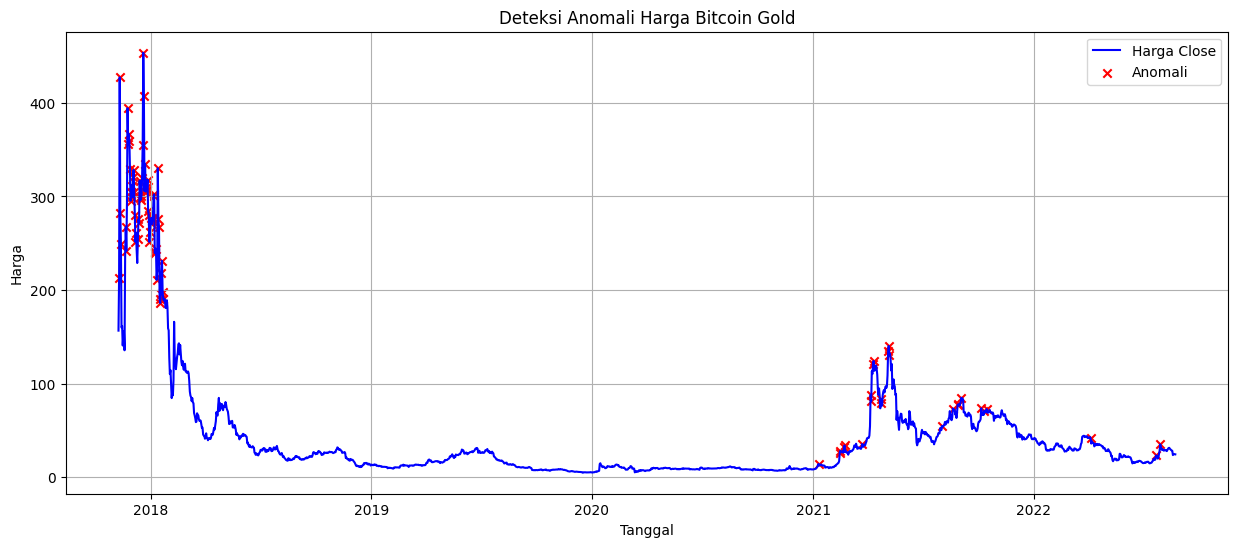

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(df['Date'], df['Close'], label='Harga Close', color='blue')
plt.scatter(df[df['anomaly'] == 1]['Date'], df[df['anomaly'] == 1]['Close'],
            color='red', label='Anomali', marker='x')
plt.title("Deteksi Anomali Harga Bitcoin Gold")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
anomali_df = df[df['anomaly'] == 1]
anomali_df.reset_index(drop=True, inplace=True)
anomali_df.head()

,Date,Close,Volume,anomaly
0,2017-11-10,213.403000,36198500.0,1
1,2017-11-11,427.135010,187191008.0,1
2,2017-11-12,282.407013,90339904.0,1
3,2017-11-13,249.220993,45916500.0,1
4,2017-11-21,267.208008,370782016.0,1


In [ ]:
print(f"Total anomali terdeteksi: {len(anomali_df)}")

Total anomali terdeteksi: 88
